In [242]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from ydata_profiling import ProfileReport
import warnings
import pickle
warnings.filterwarnings("ignore")
%matplotlib inline



In [225]:
train = pd.read_csv('D:/Projects/ML-Projects/WineQualityE2E/Data/Titanic_train.csv')
test = pd.read_csv('D:/Projects/ML-Projects/WineQualityE2E/Data/Titanic_test.csv')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 31.69it/s]


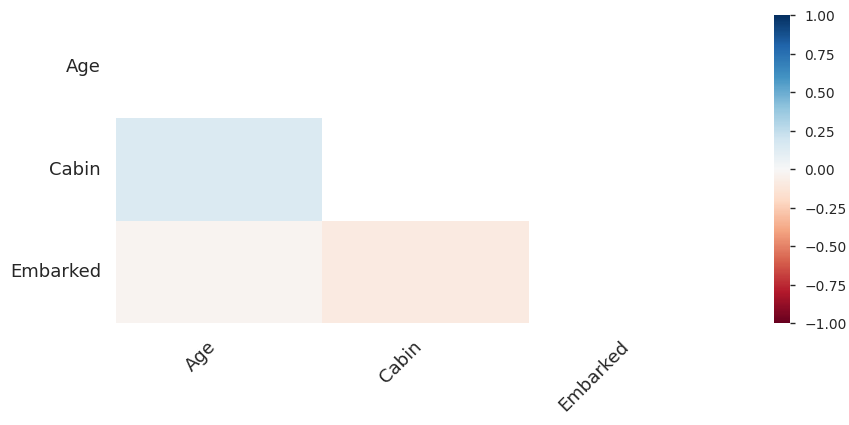

In [72]:
ProfileReport(train).to_file('D:/Projects/ML-Projects/WineQualityE2E/reports/Titanic.html')

In [111]:
train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
357,358,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S
240,241,0,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
677,678,1,3,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
145,146,0,2,"Nicholls, Mr. Joseph Charles",male,19.0,1,1,C.A. 33112,36.7500,NaN,S
144,145,0,2,"Andrew, Mr. Edgardo Samuel",male,18.0,0,0,231945,11.5000,NaN,S
502,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C


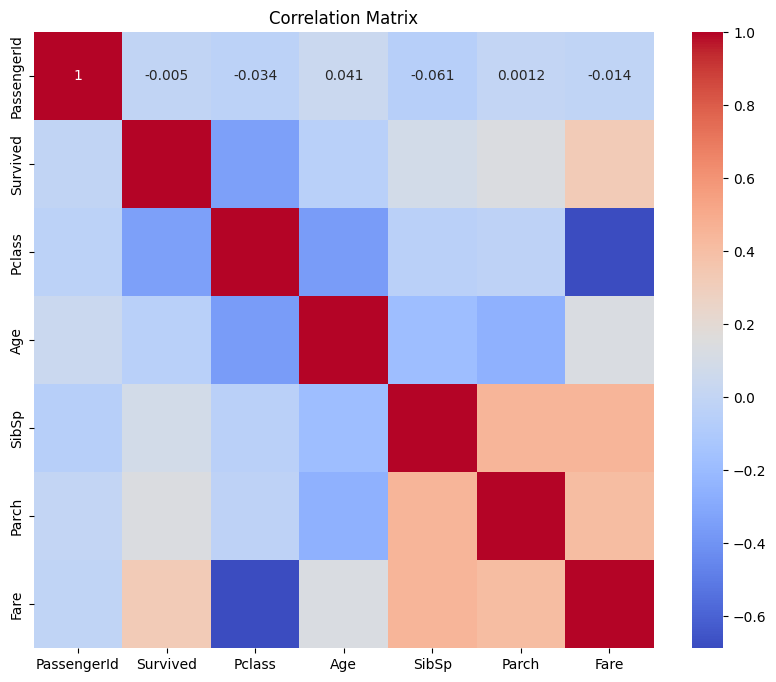

In [23]:
corr = train.select_dtypes(include=['number']).corr(method = 'spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [206]:
# Checking null & zero values
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [226]:
train[train['Embarked'].isna()]
train = train.dropna(subset=['Embarked'])
train.shape

(889, 12)

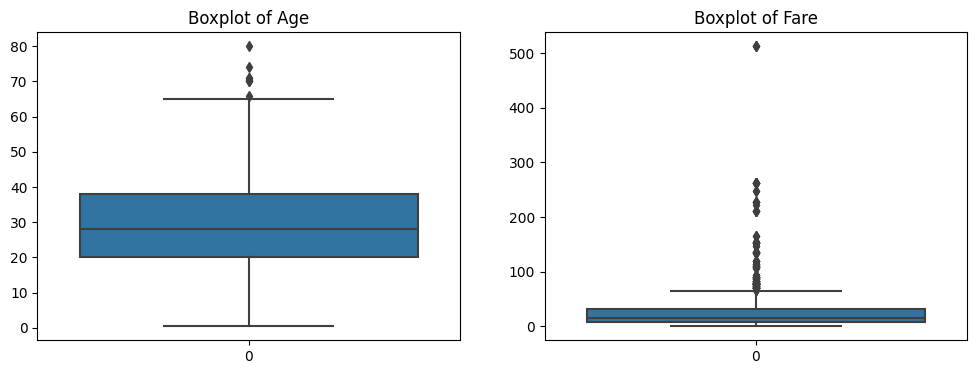

In [227]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(train['Age'])
plt.title('Boxplot of Age')
plt.subplot(1,2,2)
sns.boxplot(train['Fare'])
plt.title('Boxplot of Fare')
plt.show()

In [228]:
train = train.drop(columns=['Name', 'Ticket', 'Cabin'])
test = test.drop(columns=['Name', 'Ticket', 'Cabin'])

In [229]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived', axis=1), train['Survived'], test_size=0.2, random_state=42)

In [230]:
Nominal_features = ['Sex', 'Embarked']
Ordinal_features = ['Pclass']

In [231]:
# Imputer = KNNImputer(n_neighbors=5)
Imputer = IterativeImputer(estimator = LinearRegression(), max_iter = 10, initial_strategy = 'mean')
# X_train['Age'] = Imputer.fit_transform(X_train[['Age']])

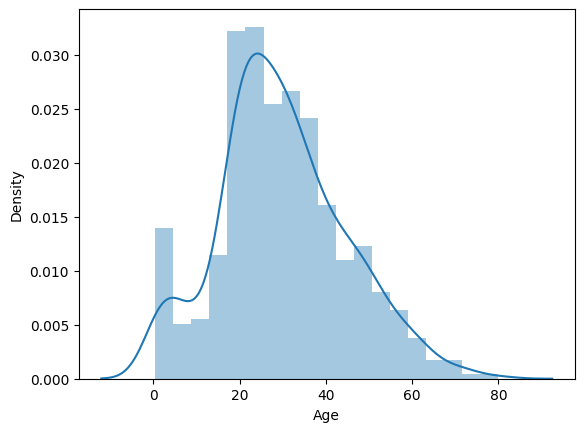

0.3453000610703805

In [232]:
sns.distplot(X_train['Age'])
plt.show()
X_train['Age'].skew()

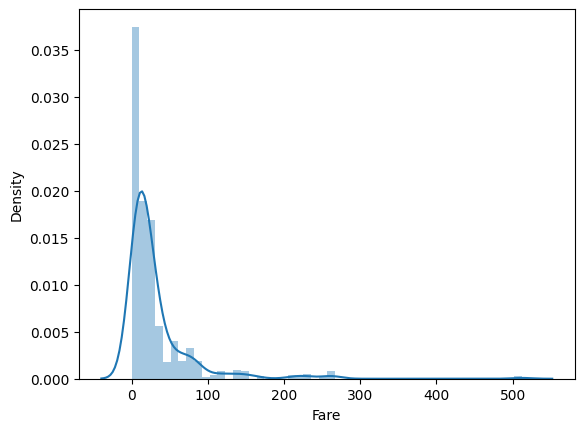

4.599917485148067

In [216]:
sns.distplot(X_train['Fare'])
plt.show()
X_train['Fare'].skew()

In [233]:
PowerTransform = PowerTransformer(method='yeo-johnson')
# X_train['Fare'] = PowerTransform.fit_transform(X_train[['Fare']])

In [234]:
NominalEncoding = OneHotEncoder(drop='first', sparse_output=False)
OrdinalEncoding = OrdinalEncoder()

In [235]:
preprocessor = ColumnTransformer(
    transformers=[
        ("Applying Transformation on Age Column",
         Pipeline(steps=[
            ("Imputing", Imputer),
            ("Transforming", PowerTransform),
            ("Scaling", StandardScaler())]),
            ['Age']),

        ("Applying Transformation on Fare Column",
         Pipeline(steps=[
            ("Imputing", Imputer),
            ("Transforming", PowerTransform),
            ("Scaling", StandardScaler())]), 
            ['Fare']),

        ("Encoding Nominal Categorical Features",
         Pipeline(steps=[
             ("NominalEncoding", NominalEncoding)]),
            Nominal_features),

        ("Encoding Ordinal Categorical Features",
         Pipeline(steps=[
             ("OrdinalEncoding", OrdinalEncoding)]),
             Ordinal_features)
        ])

In [236]:
Pipeline = Pipeline(steps=[
    ('Preprocessing', preprocessor),
    ('Classifier', LogisticRegression())
])

In [237]:
Pipeline.fit(X_train, y_train)
y_pred = Pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7808988764044944

In [238]:
y_pred_test = Pipeline.predict(test)

In [239]:
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": y_pred_test
    })

In [240]:
submission.to_csv("TitanicSubmission.csv", index=False)

In [243]:

Pipeline = Pipeline(steps=[
    ('Preprocessing', preprocessor),
    ('Classifier', DecisionTreeClassifier())
])
Pipeline.fit(X_train, y_train)
y_pred = Pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7808988764044944